# IMPTC → Blind-Zone Emergence Risk Prediction
## 실제 데이터 구조 기반 전처리 & 시각화

**데이터 구조 (확인됨)**
```
imptc/
  train/ eval/ test/
    {track_id}/          ← 에이전트 1개
      track.json
        overview:   class_name, duration, first_ts, last_ts
        track_data: {'1': {ts, coordinates[x,y,z], velocity}, ...}
```

In [ ]:
# ── 0. 패키지 설치 ────────────────────────────────────────────
!pip install -q shapely networkx matplotlib seaborn pandas numpy tqdm scikit-learn
print('완료')

완료


In [ ]:
# ── 1. 임포트 ────────────────────────────────────────────────
import os, json, glob, pickle, warnings
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
import networkx as nx
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
print('임포트 완료')

임포트 완료


In [ ]:
# ── 2. Google Drive 마운트 ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── 3. 경로 & 파라미터 ───────────────────────────────────────
# ▼▼▼ 본인 Drive 경로로 수정 ▼▼▼
DATASET_PATH = '/content/drive/MyDrive/그기마(team 6)/imptc_trajectory'
SAVE_PATH    = '/content/drive/MyDrive/그기마(team 6)/지은'

SPLITS       = ['train', 'eval', 'test']
VRU_CLASSES  = {'pedestrian','cyclist','scooter','wheelchair',
                'stroller','personal_mobility','bike','vru'}

# Task 파라미터
OBS_WINDOW   = 2.0    # 관측 입력 창 (초)
PRED_HORIZON = 3.0    # 예측 지평선 (초)
OCC_RADIUS   = 2.5    # 합성 occluder 반경 [m]
BZ_DEPTH     = 25.0   # blind zone 깊이 [m]
EDGE_DIST    = 15.0   # 그래프 엣지 최대 거리 [m]
GRID_US      = 40000  # 타임스탬프 그리드 해상도 (40ms = 25Hz)

# 경로 확인
for sp in SPLITS:
    p = os.path.join(DATASET_PATH, sp)
    if os.path.exists(p):
        n = len(os.listdir(p))
        print(f'  ✅ {sp}/  →  {n} tracks')
    else:
        print(f'  ❌ {sp}/  없음')

  ✅ train/  →  3585 tracks
  ✅ eval/  →  400 tracks
  ✅ test/  →  1148 tracks


In [ ]:
# ── 4. track.json 파싱 함수 ──────────────────────────────────
def parse_track(filepath, split):
    '''
    track.json 1개 → DataFrame (agent 1개의 시계열)
    columns: ts_us, ts, x, y, z, speed, vx, vy,
             track_id, class_name, agent_type, split
    '''
    with open(filepath) as f:
        data = json.load(f)

    track_id   = os.path.basename(os.path.dirname(filepath))
    overview   = data.get('overview', {})
    class_name = overview.get('class_name', 'unknown').lower()
    track_data = data.get('track_data', {})

    if not track_data:
        return None

    rows = []
    for frame_idx, frame in track_data.items():
        coords = frame.get('coordinates', [0, 0, 0])
        rows.append({
            'frame_idx': int(frame_idx),
            'ts_us':     int(frame['ts']),
            'ts':        int(frame['ts']) / 1e6,
            'x':         float(coords[0]),
            'y':         float(coords[1]),
            'z':         float(coords[2]),
            'speed':     float(frame.get('velocity', 0)),
            'status':    int(frame.get('status', 1)),
        })

    df = pd.DataFrame(rows).sort_values('ts').reset_index(drop=True)

    # 위치 차분으로 vx, vy 계산
    dt = df['ts'].diff().clip(lower=1e-4)
    df['vx'] = df['x'].diff().fillna(0) / dt
    df['vy'] = df['y'].diff().fillna(0) / dt

    # 타임스탬프 그리드 (25Hz 스냅)
    df['ts_grid'] = (df['ts_us'] / GRID_US).round().astype(int) * GRID_US

    df['track_id']   = track_id
    df['class_name'] = class_name
    df['split']      = split
    df['agent_type'] = 'vru' if class_name in VRU_CLASSES else 'vehicle'

    return df

# ── 테스트 ────────────────────────────────────────────────────
sample_fp = os.path.join(DATASET_PATH, 'eval', '0000', 'track.json')
t = parse_track(sample_fp, 'eval')
print(f'Shape: {t.shape}')
print(f'class_name: {t["class_name"].iloc[0]},  agent_type: {t["agent_type"].iloc[0]}')
print(t[['ts', 'x', 'y', 'speed', 'vx', 'vy']].head(4))

Shape: (2188, 15)
class_name: scooter,  agent_type: vru
             ts          x          y     speed        vx        vy
0  1.679473e+09  14.913575  16.012512  5.822352       NaN       NaN
1  1.679473e+09  14.851033  15.995175  5.841068 -1.563561 -0.433417
2  1.679473e+09  14.788181  15.978258  5.858009 -1.571302 -0.422935
3  1.679473e+09  14.725043  15.961759  5.873158 -1.578432 -0.412468


In [ ]:
# ── 5. 전체 트랙 로드 ─────────────────────────────────────────
def load_all(dataset_path, splits):
    dfs = []
    for split in splits:
        sp = os.path.join(dataset_path, split)
        if not os.path.exists(sp):
            continue
        tids = sorted(os.listdir(sp))
        for tid in tqdm(tids, desc=split):
            fp = os.path.join(sp, tid, 'track.json')
            if not os.path.exists(fp):
                continue
            df = parse_track(fp, split)
            if df is not None:
                dfs.append(df)
    if not dfs:
        print('❌ 데이터 없음'); return None

    out = pd.concat(dfs, ignore_index=True)
    print(f'\n✅ 로딩 완료')
    print(f'   관측수:  {len(out):,}')
    print(f'   트랙수:  {out["track_id"].nunique()}')
    print(f'   클래스 분포:')
    cc = out.groupby('class_name')['track_id'].nunique().sort_values(ascending=False)
    for cls, cnt in cc.items():
        tag = '← VRU' if cls in VRU_CLASSES else ''
        print(f'     {cls:<22} {cnt:>5} tracks  {tag}')
    return out

df_all = load_all(DATASET_PATH, SPLITS)

train:   0%|          | 0/3585 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Cell 5 대체 — eval만, 최대 50개 트랙으로 테스트
def load_all(dataset_path, splits, max_per_split=None):
    dfs = []
    for split in splits:
        sp = os.path.join(dataset_path, split)
        if not os.path.exists(sp): continue
        tids = sorted(os.listdir(sp))
        if max_per_split:
            tids = tids[:max_per_split]
        for tid in tqdm(tids, desc=split):
            fp = os.path.join(sp, tid, 'track.json')
            if not os.path.exists(fp): continue
            df = parse_track(fp, split)
            if df is not None:
                dfs.append(df)
    if not dfs:
        print('❌ 데이터 없음'); return None
    out = pd.concat(dfs, ignore_index=True)
    print(f'✅ 로딩 완료: {len(out):,} 관측, {out["track_id"].nunique()} 트랙')
    print(out.groupby('class_name')['track_id'].nunique().to_dict())
    return out

# 일단 eval 50개만
df_all = load_all(DATASET_PATH, ['eval'], max_per_split=50)

eval:   0%|          | 0/50 [00:00<?, ?it/s]

✅ 로딩 완료: 38,451 관측, 50 트랙
{'bicycle': 8, 'person': 39, 'scooter': 3}


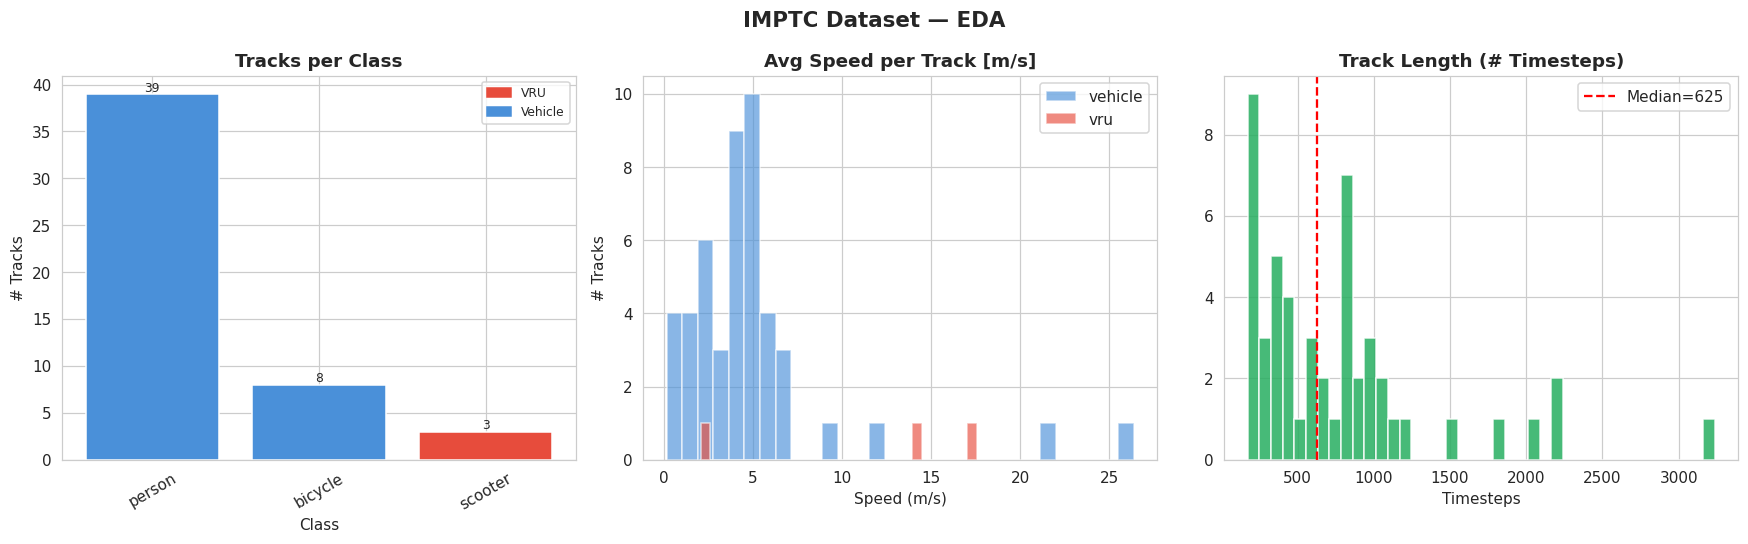

총 트랙 50개  |  VRU: 2,704  관측


In [ ]:
# ── 6. EDA: 클래스 & 속도 & 트랙 길이 분포 ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('IMPTC Dataset — EDA', fontsize=14, fontweight='bold')

# 클래스별 트랙 수
ax = axes[0]
cc = df_all.groupby('class_name')['track_id'].nunique().sort_values(ascending=False)
colors = ['#E74C3C' if c in VRU_CLASSES else '#4A90D9' for c in cc.index]
bars = ax.bar(cc.index, cc.values, color=colors, edgecolor='white')
ax.set_title('Tracks per Class', fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('# Tracks')
ax.tick_params(axis='x', rotation=30)
for bar, v in zip(bars, cc.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, str(v), ha='center', fontsize=8)
ax.legend(handles=[
    mpatches.Patch(color='#E74C3C', label='VRU'),
    mpatches.Patch(color='#4A90D9', label='Vehicle')
], fontsize=8)

# 평균 속도 분포
ax = axes[1]
avg_spd = df_all.groupby('track_id').agg(
    speed=('speed','mean'),
    agent_type=('agent_type','first')
).reset_index()
for atype, c in [('vehicle','#4A90D9'),('vru','#E74C3C')]:
    sub = avg_spd[avg_spd['agent_type']==atype]['speed']
    ax.hist(sub, bins=30, color=c, alpha=0.65, label=atype, edgecolor='white')
ax.set_title('Avg Speed per Track [m/s]', fontweight='bold')
ax.set_xlabel('Speed (m/s)'); ax.set_ylabel('# Tracks')
ax.legend()

# 트랙 길이(관측 수) 분포
ax = axes[2]
tl = df_all.groupby('track_id').size()
ax.hist(tl, bins=40, color='#27AE60', edgecolor='white', alpha=0.85)
med = tl.median()
ax.axvline(med, color='red', linestyle='--', label=f'Median={med:.0f}')
ax.set_title('Track Length (# Timesteps)', fontweight='bold')
ax.set_xlabel('Timesteps'); ax.legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'총 트랙 {df_all["track_id"].nunique()}개  |  VRU: {(df_all["agent_type"]=="vru").sum():,}  관측')

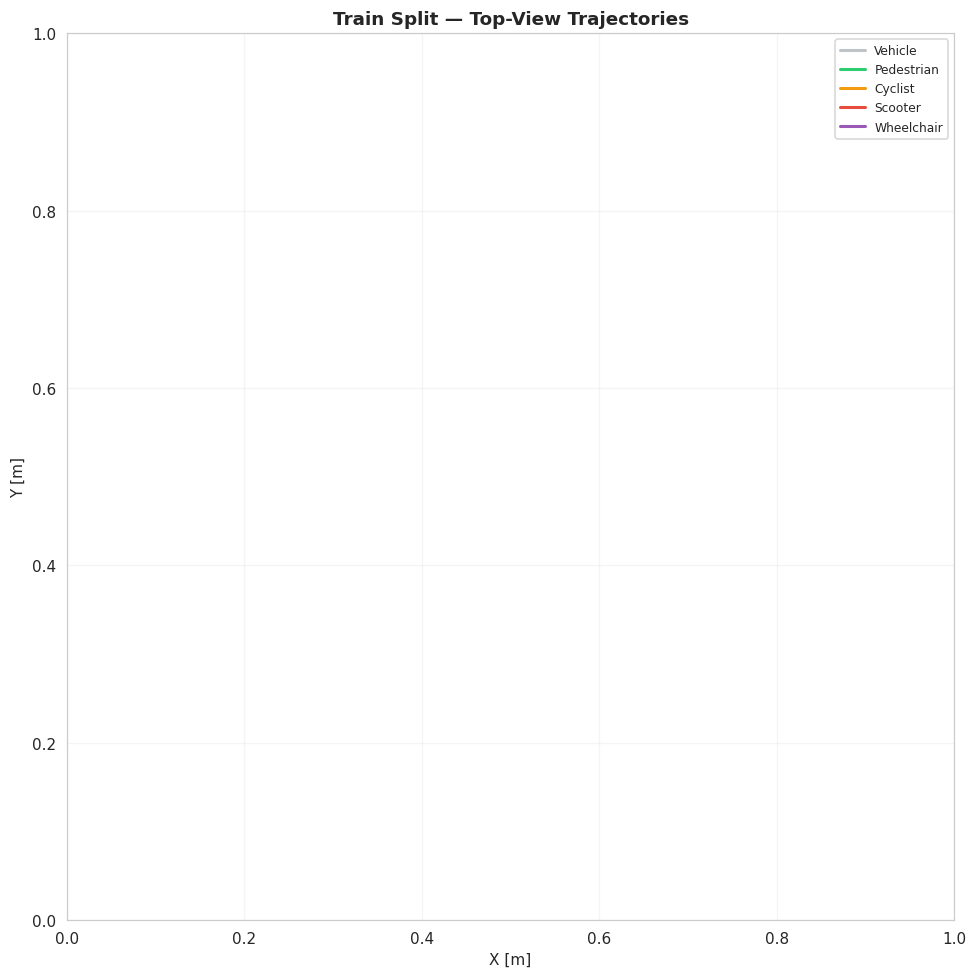

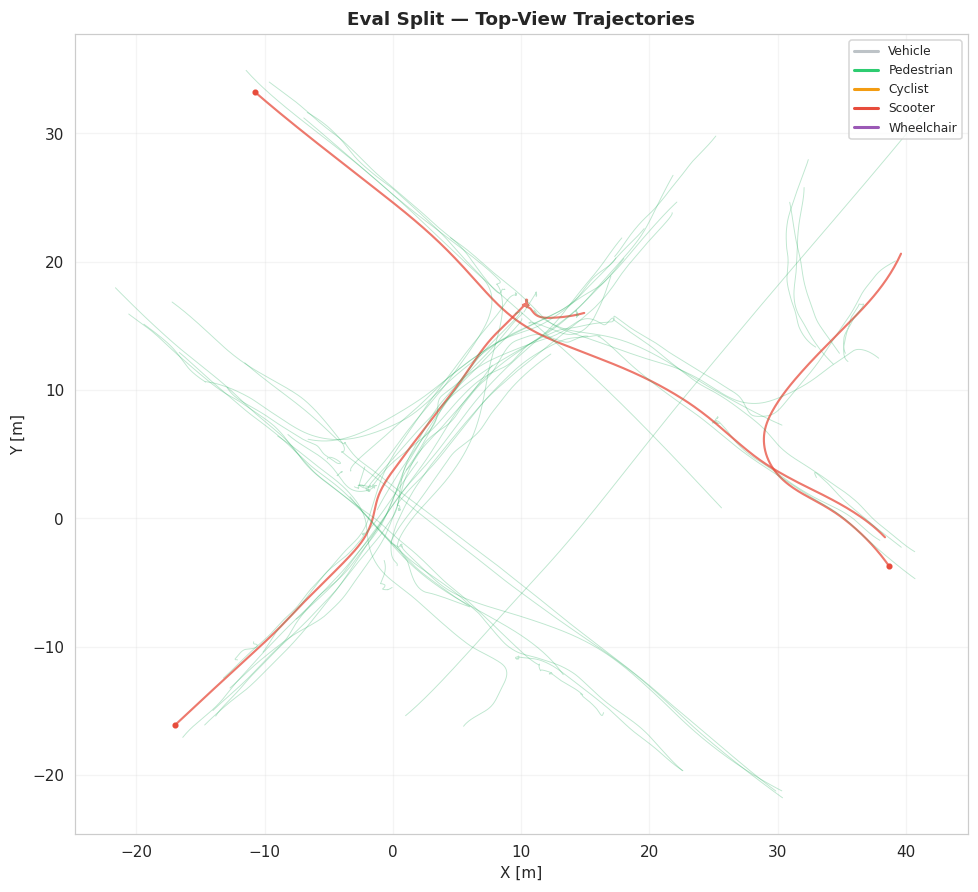

In [ ]:
# ── 7. EDA: Top-View 궤적 시각화 ─────────────────────────────
CLASS_COLOR = {
    'vehicle':'#BDC3C7', 'pedestrian':'#2ECC71',
    'cyclist':'#F39C12', 'scooter':'#E74C3C',
    'wheelchair':'#9B59B6', 'stroller':'#1ABC9C',
    'default':'#27AE60'
}

def plot_trajectories(df, split_filter=None, max_tracks=150, title='Trajectories'):
    data = df[df['split']==split_filter] if split_filter else df
    fig, ax = plt.subplots(figsize=(9, 9))

    groups = list(data.groupby(['track_id','class_name']))
    if len(groups) > max_tracks:
        import random; random.seed(0)
        groups = random.sample(groups, max_tracks)

    for (tid, cls), grp in groups:
        grp = grp.sort_values('ts')
        x, y = grp['x'].values, grp['y'].values
        c = CLASS_COLOR.get(cls, CLASS_COLOR['default'])
        alpha = 0.3 if cls not in VRU_CLASSES else 0.75
        lw    = 0.6 if cls not in VRU_CLASSES else 1.4
        ax.plot(x, y, color=c, alpha=alpha, lw=lw)
        if cls in VRU_CLASSES:
            ax.plot(x[-1], y[-1], 'o', color=c, ms=3)

    legend_h = [
        Line2D([0],[0], color='#BDC3C7', lw=2, label='Vehicle'),
        Line2D([0],[0], color='#2ECC71', lw=2, label='Pedestrian'),
        Line2D([0],[0], color='#F39C12', lw=2, label='Cyclist'),
        Line2D([0],[0], color='#E74C3C', lw=2, label='Scooter'),
        Line2D([0],[0], color='#9B59B6', lw=2, label='Wheelchair'),
    ]
    ax.legend(handles=legend_h, fontsize=8, loc='upper right')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    return fig, ax

fig, ax = plot_trajectories(df_all, split_filter='train',
                            title='Train Split — Top-View Trajectories')
plt.tight_layout()
plt.savefig('trajectories_train.png', dpi=150, bbox_inches='tight')
plt.show()

# eval 전체
fig, ax = plot_trajectories(df_all, split_filter='eval',
                            title='Eval Split — Top-View Trajectories')
plt.tight_layout()
plt.savefig('trajectories_eval.png', dpi=150, bbox_inches='tight')
plt.show()

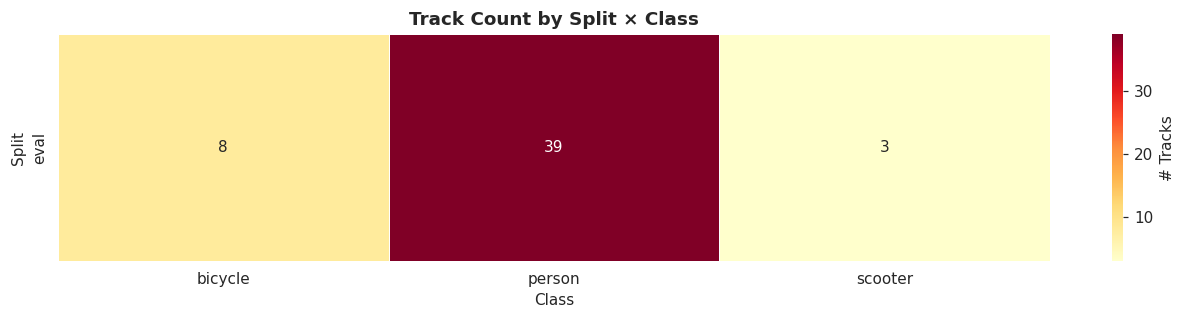

class_name  bicycle  person  scooter
split                               
eval              8      39        3


In [ ]:
# ── 8. EDA: Split별 클래스 비교 히트맵 ───────────────────────
pivot = df_all.groupby(['split','class_name'])['track_id'].nunique().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '# Tracks'})
ax.set_title('Track Count by Split × Class', fontsize=12, fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Split')
plt.tight_layout()
plt.savefig('split_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(pivot)

In [ ]:
# ── 9. Blind Zone 기하 함수 ──────────────────────────────────
def compute_blind_zone(ego_pos, occ_pos, occ_r=2.5, depth=25.0):
    '''
    Ego 위치에서 occluder 뒤쪽 사각지대 폴리곤 반환.
    '''
    ex, ey = ego_pos
    ox, oy = occ_pos
    dist = np.hypot(ox - ex, oy - ey)
    if dist <= occ_r:
        return None
    angle_c = np.arctan2(oy - ey, ox - ex)
    half_a  = np.arcsin(min(occ_r / dist, 1.0))
    al, ar  = angle_c + half_a, angle_c - half_a
    tl = (ox - occ_r * np.sin(angle_c), oy + occ_r * np.cos(angle_c))
    tr = (ox + occ_r * np.sin(angle_c), oy - occ_r * np.cos(angle_c))
    fl = (ox + depth * np.cos(al),      oy + depth * np.sin(al))
    fc = (ox + depth * np.cos(angle_c), oy + depth * np.sin(angle_c))
    fr = (ox + depth * np.cos(ar),      oy + depth * np.sin(ar))
    poly = Polygon([tl, fl, fc, fr, tr])
    return poly if poly.is_valid else poly.buffer(0)

# 빠른 확인
bz = compute_blind_zone((0,0), (10,0), 2.5, 20)
print(f'BZ area: {bz.area:.1f} m²')
print(f'(15,0) in BZ: {bz.contains(Point(15,0))}')  # True
print(f'( 5,0) in BZ: {bz.contains(Point(5,0))}')   # False

BZ area: 148.4 m²
(15,0) in BZ: True
( 5,0) in BZ: False


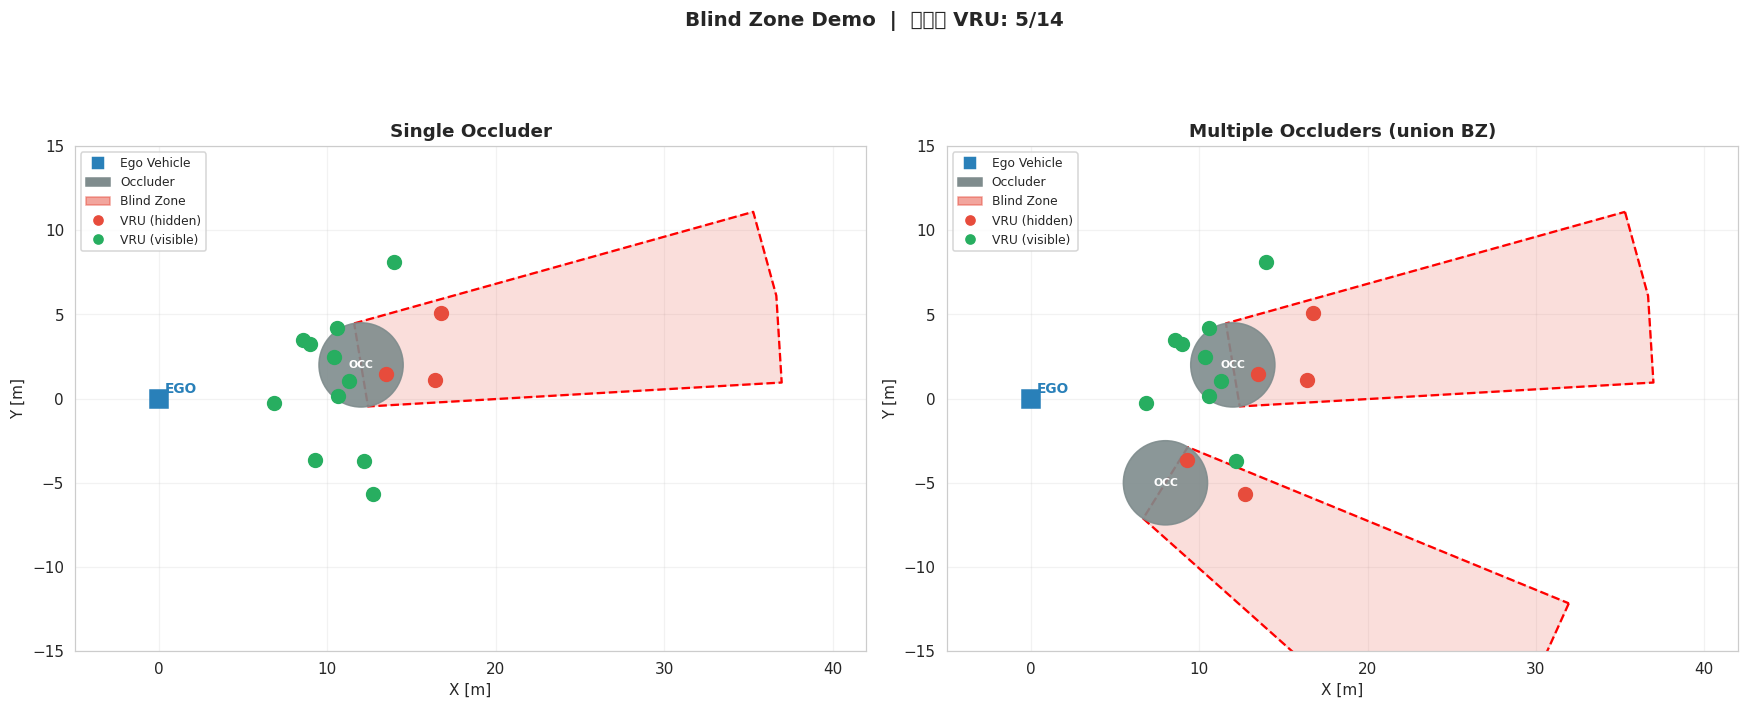

In [ ]:
# ── 10. Blind Zone 시각화 데모 ───────────────────────────────
np.random.seed(42)
EGO  = np.array([0.0, 0.0])
OCC1 = np.array([12.0, 2.0])
OCC2 = np.array([8.0, -5.0])

bz1 = compute_blind_zone(EGO, OCC1, OCC_RADIUS, BZ_DEPTH)
bz2 = compute_blind_zone(EGO, OCC2, OCC_RADIUS, BZ_DEPTH)
bz_union = unary_union([b for b in [bz1, bz2] if b])
VRU_PTS = [(12 + np.random.randn()*3, 2 + np.random.randn()*4) for _ in range(14)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ai, (bz_list, occs, ttl) in enumerate([
    ([bz1],       [OCC1],        'Single Occluder'),
    ([bz1, bz2],  [OCC1, OCC2],  'Multiple Occluders (union BZ)'),
]):
    ax = axes[ai]
    bz_u = unary_union([b for b in bz_list if b])

    # Polygon / MultiPolygon 둘 다 처리
    from shapely.geometry import MultiPolygon
    polys = list(bz_u.geoms) if isinstance(bz_u, MultiPolygon) else [bz_u]
    for pi, poly in enumerate(polys):
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, alpha=0.18, color='#E74C3C')
        ax.plot(xs, ys, 'r--', lw=1.5, label='Blind Zone' if pi==0 else '')
    for occ in occs:
        ax.add_patch(plt.Circle(occ, OCC_RADIUS, color='#7F8C8D', alpha=0.9, zorder=5))
        ax.text(*occ, 'OCC', ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=6)
    ax.plot(*EGO, 's', color='#2980B9', ms=12, zorder=7)
    ax.annotate('EGO', EGO, xytext=(4,4), textcoords='offset points',
                color='#2980B9', fontsize=9, fontweight='bold')
    for pos in VRU_PTS:
        in_bz = bz_u.contains(Point(pos))
        ax.plot(*pos, 'o', color='#E74C3C' if in_bz else '#27AE60', ms=9, zorder=8)
    legend_h = [
        Line2D([0],[0], marker='s', color='w', markerfacecolor='#2980B9', ms=9, label='Ego Vehicle'),
        mpatches.Patch(color='#7F8C8D', label='Occluder'),
        mpatches.Patch(color='#E74C3C', alpha=0.5, label='Blind Zone'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#E74C3C', ms=8, label='VRU (hidden)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#27AE60', ms=8, label='VRU (visible)'),
    ]
    ax.legend(handles=legend_h, fontsize=8, loc='upper left')
    ax.set_xlim(-5, 42); ax.set_ylim(-15, 15)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
    ax.set_title(ttl, fontsize=12, fontweight='bold')
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')

n_hid = sum(bz_union.contains(Point(p)) for p in VRU_PTS)
plt.suptitle(f'Blind Zone Demo  |  숨겨진 VRU: {n_hid}/{len(VRU_PTS)}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('blind_zone_demo.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 11. 씬 구성 & 라벨 생성 ──────────────────────────────────
#
# 구조: train/eval/test 각 split 내 모든 에이전트는
# 같은 교차로를 지나며 시간이 겹치는 에이전트끼리 공존함.
# → ts_grid 기준으로 같은 시점에 존재하는 에이전트를 씬으로 묶음.

def build_pos_index(df):
    '''track_id → {ts_grid → (x, y)} 딕셔너리 반환'''
    idx = {}
    for tid, grp in df.groupby('track_id'):
        idx[tid] = dict(zip(grp['ts_grid'], zip(grp['x'], grp['y'])))
    return idx

def build_ts_to_agents(df):
    '''ts_grid → 해당 시점에 존재하는 track_id 목록'''
    ts2ag = defaultdict(list)
    meta  = df.groupby('track_id').agg(
        class_name=('class_name','first'),
        agent_type=('agent_type','first'),
        avg_speed =('speed','mean')
    ).to_dict('index')
    for tid, grp in df.groupby('track_id'):
        for gt in grp['ts_grid'].unique():
            ts2ag[gt].append(tid)
    return ts2ag, meta

def generate_labels_for_split(df_split, split_name,
                               obs_window=2.0, pred_horizon=3.0,
                               occ_r=2.5, bz_d=25.0):
    '''
    한 split의 모든 에이전트 데이터에서
    blind-zone emergence 샘플 생성.
    '''
    samples = []
    pos_idx          = build_pos_index(df_split)
    ts2ag, meta      = build_ts_to_agents(df_split)
    all_grid_ts      = sorted(ts2ag.keys())

    obs_steps  = int(obs_window  / (GRID_US / 1e6))
    pred_steps = int(pred_horizon / (GRID_US / 1e6))

    vru_ids = [tid for tid, m in meta.items() if m['agent_type'] == 'vru']
    veh_ids = [tid for tid, m in meta.items() if m['agent_type'] == 'vehicle']

    if not vru_ids or not veh_ids:
        return samples

    # Occluder 후보: 저속 vehicle
    occ_candidates = sorted(veh_ids,
                            key=lambda t: meta[t]['avg_speed'])[:min(3, len(veh_ids))]

    for i in tqdm(range(obs_steps, len(all_grid_ts) - pred_steps),
                  desc=f'{split_name} 라벨 생성', leave=False):
        t_now  = all_grid_ts[i]
        t_past = all_grid_ts[i - obs_steps]
        t_fut  = all_grid_ts[i + pred_steps]

        # 현 시점 공존 에이전트
        active = set(ts2ag[t_now])
        active_vru = [v for v in vru_ids if v in active]
        active_veh = [v for v in veh_ids if v in active]
        active_occ = [v for v in occ_candidates if v in active]

        if not active_vru or not active_veh or not active_occ:
            continue

        # Ego: 가장 빠른 vehicle
        ego_id = max(active_veh, key=lambda t: meta[t]['avg_speed'])
        ego_pos = pos_idx[ego_id].get(t_now)
        if ego_pos is None:
            continue

        # Blind zones
        bz_list, occ_info = [], []
        for oid in active_occ:
            occ_pos = pos_idx[oid].get(t_now)
            if occ_pos is None:
                continue
            bz = compute_blind_zone(ego_pos, occ_pos, occ_r, bz_d)
            if bz:
                bz_list.append(bz)
                occ_info.append((oid, occ_pos))
        if not bz_list:
            continue

        bz_union = unary_union(bz_list)
        fut_ts   = all_grid_ts[i:i + pred_steps]

        for vid in active_vru:
            vru_pos = pos_idx[vid].get(t_now)
            if vru_pos is None or not bz_union.contains(Point(vru_pos)):
                continue

            # 라벨: 향후 pred_horizon 초 내 visible zone으로 출현?
            label = int(any(
                (p := pos_idx[vid].get(ft)) is not None
                and not bz_union.contains(Point(p))
                for ft in fut_ts
            ))

            samples.append({
                'split':     split_name,
                'ego_id':    ego_id,
                'vru_id':    vid,
                'vru_class': meta[vid]['class_name'],
                't_now_us':  t_now,
                'ego_pos':   ego_pos,
                'vru_pos':   vru_pos,
                'occluders': occ_info,
                'label':     label,
            })
    return samples

# ── 전체 처리 ─────────────────────────────────────────────────
all_samples = []
for split in SPLITS:
    df_split = df_all[df_all['split'] == split]
    if len(df_split) == 0:
        continue
    s = generate_labels_for_split(df_split, split,
                                   OBS_WINDOW, PRED_HORIZON, OCC_RADIUS, BZ_DEPTH)
    all_samples.extend(s)
    n_pos = sum(x['label'] for x in s)
    print(f'  {split}: {len(s)} 샘플  (pos={n_pos}, neg={len(s)-n_pos})')

print(f'\n총 샘플: {len(all_samples):,}')
if all_samples:
    n_p = sum(x['label'] for x in all_samples)
    print(f'Positive: {n_p:,}  ({100*n_p/len(all_samples):.1f}%)')
    print(f'Negative: {len(all_samples)-n_p:,}')

eval 라벨 생성:   0%|          | 0/33975 [00:00<?, ?it/s]

  eval: 0 샘플  (pos=0, neg=0)

총 샘플: 0


In [ ]:
# 진단: 로드된 트랙들의 타임스탬프 범위 확인
diag = df_all.groupby(['track_id', 'class_name', 'agent_type']).agg(
    ts_min=('ts', 'min'),
    ts_max=('ts', 'max'),
    n_frames=('ts', 'count')
).reset_index()

print(f"agent_type 분포:\n{diag['agent_type'].value_counts()}\n")
print(f"class_name 분포:\n{diag['class_name'].value_counts()}\n")

# 타임스탬프 범위가 겹치는지 확인
print(f"ts_min 범위: {diag['ts_min'].min():.0f} ~ {diag['ts_min'].max():.0f}")
print(f"ts_max 범위: {diag['ts_max'].min():.0f} ~ {diag['ts_max'].max():.0f}")
print(f"\n시간 범위 차이: {diag['ts_min'].max() - diag['ts_min'].min():.1f} 초")

agent_type 분포:
agent_type
vehicle    47
vru         3
Name: count, dtype: int64

class_name 분포:
class_name
person     39
bicycle     8
scooter     3
Name: count, dtype: int64

ts_min 범위: 1679472907 ~ 1685080567
ts_max 범위: 1679472995 ~ 1685080575

시간 범위 차이: 5607659.8 초


In [ ]:
# ── 12. 데이터셋 통계 시각화 ─────────────────────────────────
if not all_samples:
    print('샘플 없음 — OCC_RADIUS / BZ_DEPTH 파라미터 조정 필요')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Blind-Zone Emergence Dataset Statistics',
                 fontsize=14, fontweight='bold')

    labels  = [s['label']     for s in all_samples]
    classes = [s['vru_class'] for s in all_samples]
    splits  = [s['split']     for s in all_samples]
    n_pos   = sum(labels)
    n_neg   = len(labels) - n_pos

    # 라벨 분포
    ax = axes[0][0]
    ax.bar(['Negative\n(숨김)', 'Positive\n(출현)'], [n_neg, n_pos],
           color=['#3498DB','#E74C3C'], edgecolor='white')
    ax.set_title('Label Distribution', fontweight='bold')
    for i,(cnt,tot) in enumerate([(n_neg,len(labels)),(n_pos,len(labels))]):
        ax.text(i, cnt + max(n_pos,n_neg)*0.01,
                f'{cnt:,}\n({100*cnt/tot:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')

    # VRU 클래스 분포
    ax = axes[0][1]
    cc2 = Counter(classes)
    ax.bar(cc2.keys(), cc2.values(),
           color=sns.color_palette('Set2', len(cc2)))
    ax.set_title('VRU Class in Samples', fontweight='bold')
    ax.tick_params(axis='x', rotation=25)

    # 클래스별 Positive rate
    ax = axes[1][0]
    pos_by_cls = defaultdict(list)
    for s in all_samples:
        pos_by_cls[s['vru_class']].append(s['label'])
    cls_names  = list(pos_by_cls.keys())
    pos_rates  = [np.mean(pos_by_cls[c])*100 for c in cls_names]
    bars = ax.bar(cls_names, pos_rates,
                  color=sns.color_palette('Set1', len(cls_names)))
    ax.set_title('Positive Rate by VRU Class (%)', fontweight='bold')
    ax.set_ylim(0, 100); ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, pos_rates):
        ax.text(bar.get_x()+bar.get_width()/2, v+1,
                f'{v:.1f}%', ha='center', fontsize=9)

    # Split별 샘플 분포
    ax = axes[1][1]
    sp_cnt = Counter(splits)
    ax.bar(sp_cnt.keys(), sp_cnt.values(),
           color=sns.color_palette('Paired', len(sp_cnt)))
    ax.set_title('Samples per Split', fontweight='bold')

    plt.tight_layout()
    plt.savefig('dataset_stats.png', dpi=150, bbox_inches='tight')
    plt.show()

샘플 없음 — OCC_RADIUS / BZ_DEPTH 파라미터 조정 필요


In [ ]:
# ── 13. Emergence 이벤트 시각화 ──────────────────────────────
def visualize_emergence(sample, df_all, occ_r=2.5, bz_d=25.0):
    split    = sample['split']
    ego_pos  = sample['ego_pos']
    vid      = sample['vru_id']
    t_now_us = sample['t_now_us']
    t_now_s  = t_now_us / 1e6

    vru_traj = df_all[
        (df_all['split'] == split) & (df_all['track_id'] == vid)
    ].sort_values('ts')

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    offsets = [0.0, PRED_HORIZON / 2, PRED_HORIZON]
    titles  = ['t = 0 (현재)', f't = +{PRED_HORIZON/2:.1f}s', f't = +{PRED_HORIZON:.0f}s']

    for ax, t_off, ttl in zip(axes, offsets, titles):
        for occ_id, occ_pos in sample['occluders']:
            bz = compute_blind_zone(ego_pos, occ_pos, occ_r, bz_d)
            if bz:
                xs, ys = bz.exterior.xy
                ax.fill(xs, ys, alpha=0.15, color='#E74C3C')
                ax.plot(xs, ys, 'r--', lw=1.3)
            ax.add_patch(plt.Circle(occ_pos, occ_r, color='#7F8C8D', alpha=0.85, zorder=5))

        ax.plot(*ego_pos, 's', color='#2980B9', ms=11, zorder=7, label='Ego')

        # VRU 궤적 (과거 → 현재)
        past = vru_traj[vru_traj['ts'] <= t_now_s]
        if len(past):
            ax.plot(past['x'], past['y'], 'g-', alpha=0.4, lw=1.3)

        # VRU 위치 at t_now + t_off
        target_s = t_now_s + t_off
        close    = vru_traj.iloc[(vru_traj['ts'] - target_s).abs().argsort()[:1]]
        if len(close):
            c = '#E74C3C' if t_off == 0 else ('#F39C12' if t_off < PRED_HORIZON else '#27AE60')
            ax.plot(close['x'].iloc[0], close['y'].iloc[0],
                    'o', color=c, ms=11, zorder=8, label=f'VRU +{t_off:.1f}s')

        lbl_str = f'Label={sample["label"]} ({"출현✅" if sample["label"] else "미출현❌"})'
        full_t  = f'{ttl}\n{lbl_str}' if t_off == PRED_HORIZON else ttl
        ax.set_title(full_t, fontsize=10, fontweight='bold')
        ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
        ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc='upper left')

    plt.suptitle(
        f'Emergence Event | split={split} | VRU={vid} | class={sample["vru_class"]}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'emergence_{split}_{vid}.png', dpi=150, bbox_inches='tight')
    plt.show()

pos_samples = [s for s in all_samples if s['label'] == 1]
neg_samples = [s for s in all_samples if s['label'] == 0]
print(f'Positive 샘플: {len(pos_samples)},  Negative: {len(neg_samples)}')

if pos_samples:
    print('=== Positive 시각화 (VRU 출현) ===')
    visualize_emergence(pos_samples[0], df_all)
if neg_samples:
    print('=== Negative 시각화 (미출현) ===')
    visualize_emergence(neg_samples[0], df_all)

Positive 샘플: 0,  Negative: 0


In [ ]:
# ── 14. 처리된 데이터 저장 ────────────────────────────────────
import shutil
os.makedirs(SAVE_PATH, exist_ok=True)

# 샘플 메타데이터
with open(f'{SAVE_PATH}/samples.pkl', 'wb') as f:
    pickle.dump(all_samples, f)
print(f'✅ samples.pkl  ({len(all_samples):,} 샘플)')

# 요약 CSV
summary = pd.DataFrame([{
    'split':       s['split'],
    'vru_id':      s['vru_id'],
    'vru_class':   s['vru_class'],
    'ego_id':      s['ego_id'],
    't_now_us':    s['t_now_us'],
    'label':       s['label'],
    'n_occluders': len(s['occluders']),
} for s in all_samples])
summary.to_csv(f'{SAVE_PATH}/samples_summary.csv', index=False)
print(f'✅ samples_summary.csv  ({len(summary)} rows)')

# 전체 트랙 DataFrame
df_all.to_parquet(f'{SAVE_PATH}/all_tracks.parquet', index=False)
print(f'✅ all_tracks.parquet  ({len(df_all):,} rows)')

# 시각화 PNG 복사
for png in glob.glob('*.png'):
    shutil.copy(png, f'{SAVE_PATH}/{png}')

print(f'\n=== 저장 완료: {SAVE_PATH} ===')
for fn in sorted(os.listdir(SAVE_PATH)):
    sz = os.path.getsize(f'{SAVE_PATH}/{fn}') / 1024 / 1024
    print(f'  {fn}  ({sz:.2f} MB)')

✅ samples.pkl  (0 샘플)
✅ samples_summary.csv  (0 rows)
✅ all_tracks.parquet  (38,451 rows)

=== 저장 완료: /content/drive/MyDrive/그기마(team 6)/지은 ===
  IMPTC_BlindZone_GraphML.ipynb  (0.53 MB)
  all_tracks.parquet  (3.02 MB)
  blind_zone_demo.png  (0.12 MB)
  eda_overview.png  (0.08 MB)
  samples.pkl  (0.00 MB)
  samples_summary.csv  (0.00 MB)
  split_class_heatmap.png  (0.03 MB)
  trajectories_eval.png  (0.27 MB)
  trajectories_train.png  (0.04 MB)


---
## 다음 단계

```python
# 저장된 데이터 불러오기
import pickle, pandas as pd
with open('samples.pkl', 'rb') as f:
    samples = pickle.load(f)
df_all = pd.read_parquet('all_tracks.parquet')
```

| 모델 단계 | 설명 |
|----------|------|
| Rule-based | Ego↔BZ 거리 기반 위험도 점수 |
| MLP / LSTM | 노드 피처 flatten → 이진 분류 |
| **GraphSAGE** | HeteroData 이종 그래프 학습 |
| **ST-GNN + GRU** | 시공간 그래프 (GNN per frame → GRU) |

**평가 지표:** F1, Recall, AUROC, AUPRC (false negative 최소화 focus)